<a href="https://colab.research.google.com/github/sonamgupta21062003-cmyk/Credit_Risk/blob/main/basic_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder ,StandardScaler
from sklearn.model_selection import train_test_split ,cross_val_score ,GridSearchCV
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras.models import Sequential      #Sequential lets you built a neural network layer-by-layer in keras
from tensorflow.keras.layers import Dense          #Dence makes the final prediction
from tensorflow.keras.layers import Conv2D        # Conv2D extracts features
from tensorflow.keras.layers import Flatten       # Flattten reshapes them

from tensorflow.keras.layers import MaxPooling2D  #MaxPooling reduce size
from tensorflow.keras.layers import Dropout       # Dropout Prevents overfitting
from tensorflow.keras.utils import to_categorical   # converts numerical class labels into one hot encoded for training classification models


In [25]:
df = pd.read_csv('mnist_train.csv', header=None)
df_test = pd.read_csv('mnist_test.csv', header=None)

In [26]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       775, 776, 777, 778, 779, 780, 781, 782, 783, 784],
      dtype='int64', length=785)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11472 entries, 0 to 11471
Columns: 785 entries, 0 to 784
dtypes: float64(27), int64(758)
memory usage: 68.7 MB


In [29]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
780,1
781,1
782,1
783,1


In [30]:
# Fill null values with 0 in both training and test DataFrames
df.fillna(0, inplace=True)
df_test.fillna(0, inplace=True)

In [31]:
df.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
780,0
781,0
782,0
783,0


In [32]:
# preprocess
x_train = df.drop(0,axis = 1).values
y_train = df[0].values
x_test = df_test.drop(0,axis = 1).values
y_test = df_test[0].values

In [33]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32")  /255.0

In [34]:
x_train_img = x_train.reshape(-1,28,28)
x_test_img = x_test.reshape(-1,28,28)

In [35]:
x_train_cat = to_categorical(y_train,10)
x_test_cat = to_categorical(y_test,10)

In [36]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [37]:
Perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')]
)

In [38]:
Perceptron.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [39]:


# Re-run the reshaping for x_train_img and x_test_img
x_train_img = x_train.reshape(-1,28,28)
x_test_img = x_test.reshape(-1,28,28)

history_percp = Perceptron.fit(x_train_img,y_train_cat,epochs = 5,batch_size = 32,validation_data = (x_test_img,y_test_cat),verbose = 1)

Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7999 - loss: 0.8328 - val_accuracy: 0.8786 - val_loss: 0.4857
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8947 - loss: 0.4142 - val_accuracy: 0.8988 - val_loss: 0.3849
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9086 - loss: 0.3462 - val_accuracy: 0.9064 - val_loss: 0.3477
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9154 - loss: 0.3129 - val_accuracy: 0.9109 - val_loss: 0.3302
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9208 - loss: 0.2910 - val_accuracy: 0.9117 - val_loss: 0.3166


In [40]:
acc_percp = Perceptron.evaluate(x_test_img,y_test_cat,verbose = 0)[1]
acc_percp

0.9117496013641357

In [41]:
# ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')]
)

In [42]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [43]:
history_ann = ann.fit(x_train_img,y_train_cat,epochs = 5,batch_size = 32,validation_data = (x_test_img,y_test_cat),verbose = 1)

Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8689 - loss: 0.4649 - val_accuracy: 0.9287 - val_loss: 0.2545
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9428 - loss: 0.1933 - val_accuracy: 0.9370 - val_loss: 0.2027
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9612 - loss: 0.1295 - val_accuracy: 0.9469 - val_loss: 0.1695
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9718 - loss: 0.0966 - val_accuracy: 0.9453 - val_loss: 0.1770
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9758 - loss: 0.0769 - val_accuracy: 0.9464 - val_loss: 0.1733


In [44]:
acc_ann = ann.evaluate(x_test_img,y_test_cat,verbose = 0)[1]
acc_ann

0.9464340806007385

In [50]:
x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

In [56]:
cnn = Sequential([Conv2D(32 , kernel_size = (3,3),activation = "relu",input_shape = (28,28,1)),
                  MaxPooling2D(pool_size = (2,2)),
                  Conv2D(64, kernel_size = (3,3), activation = "relu"),
                  MaxPooling2D(pool_size = (2,2)),
                  Flatten(),
                  Dense(128, activation = "relu"),
                  Dropout(0.5),
                  Dense(10, activation = "softmax")
                  ])

In [57]:
cnn.compile(optimizer = "adam",loss = "categorical_crossentropy",metrics = ["accuracy"])

In [58]:
history_cnn = cnn.fit(x_train_cnn,y_train_cat,epochs = 5,batch_size = 32,validation_data = (x_test_cnn,y_test_cat),verbose = 1)

Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8337 - loss: 0.5275 - val_accuracy: 0.9637 - val_loss: 0.1169
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9469 - loss: 0.1804 - val_accuracy: 0.9705 - val_loss: 0.0947
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9623 - loss: 0.1291 - val_accuracy: 0.9772 - val_loss: 0.0727
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9693 - loss: 0.1010 - val_accuracy: 0.9818 - val_loss: 0.0543
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9766 - loss: 0.0814 - val_accuracy: 0.9820 - val_loss: 0.0548


In [59]:
acc_cnn =cnn.evaluate(x_test_cnn,y_test_cat,verbose = 0)[1]
acc_cnn

0.9820420742034912

In [70]:
def plot_training(history,title) :
  plt.figure(figsize = (12,4))
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'],label = "Train")
  plt.plot(history.history['val_accuracy'],label = "val")
  plt.title(f"{title} accuracy")
  plt.legend()


  plt.subplot(1,2,2)
  plt.plot(history.history['loss'],label = "Train")
  plt.plot(history.history['val_loss'],label = "val")
  plt.title(f"{title} loss")
  plt.legend()
  plt.show()

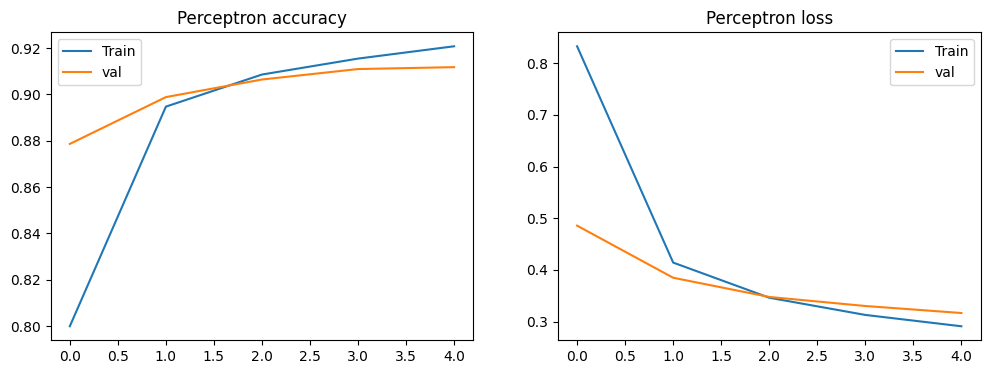

In [71]:
plot_training(history_percp,"Perceptron")

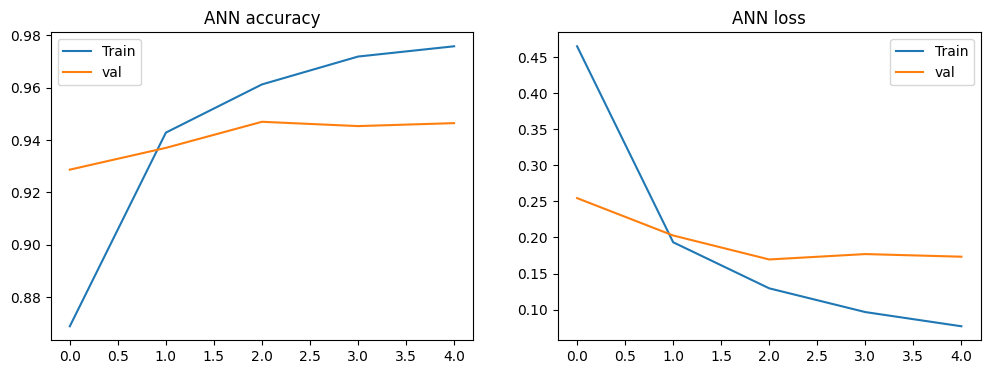

In [72]:
plot_training(history_ann , "ANN")

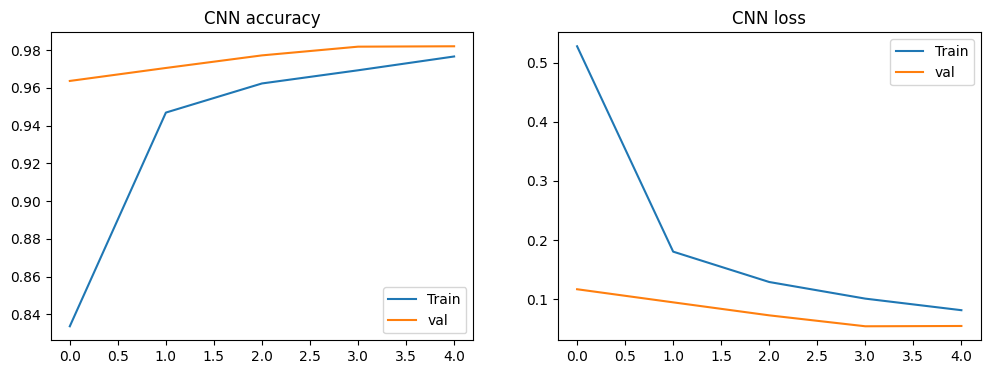

In [73]:
plot_training(history_cnn , "CNN")


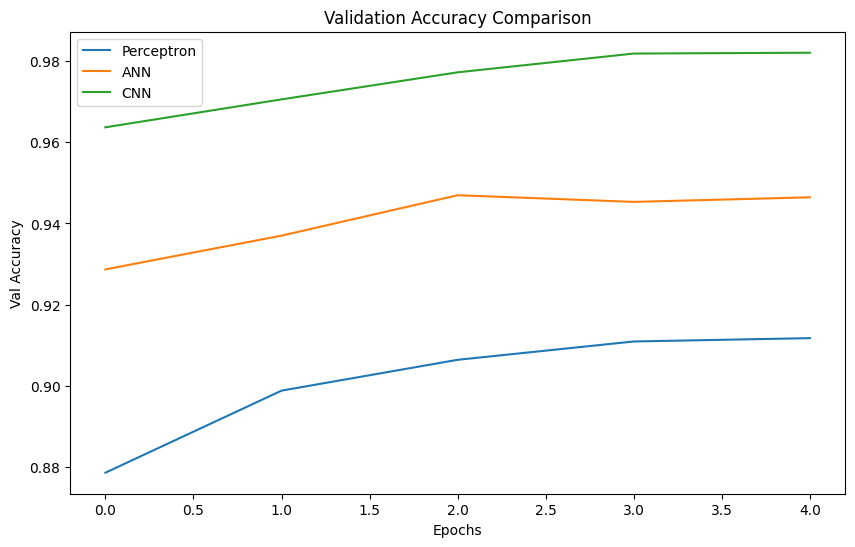

In [80]:
plt.figure(figsize = (10,6))
plt.plot(history_percp.history['val_accuracy'],label = "Perceptron")
plt.plot(history_ann.history['val_accuracy'],label = "ANN")
plt.plot(history_cnn.history['val_accuracy'],label = "CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [81]:
def show_side_by_side(models,model_names,x,x_cnn,y_cnn,y_true,n =5):
  idxs = np.random.choice(len(x),n,replace = False)
  plt.figure(figsize = (15,6))
  for i , idx in enumerate(idxs):
    plt.subplot(2,n,i+1)
    plt.imshow(x[idx].reshape(28,28),cmap = "gray")
    plt.axis("off")
    plt.title(f"True : {y_true[idx]}")
    preds = [np.argmax(model.predict(x_cnn[idx].reshape(1,28,28,1) if
                      name == "CNN" else x[idx].reshape(1,28,28)))
    for model , name in zip(models,model_names)]
    plt.subplot(2,n,n+i+1)
    plt.axis("off")
    plt.title("\n".join(f"{n} :{p}" for n ,p in zip(model_names , preds)))
    plt.tight_layout()
    plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


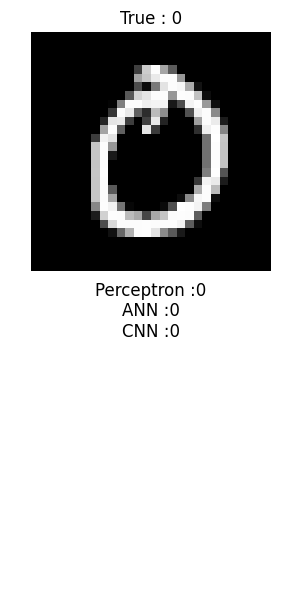

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


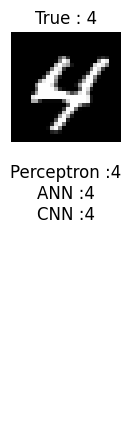

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


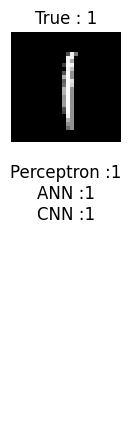

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


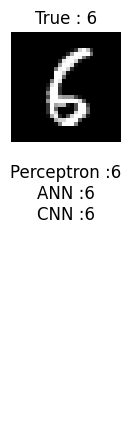

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


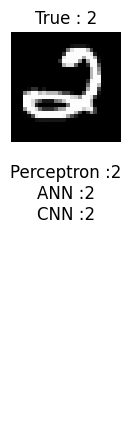

In [82]:
show_side_by_side([Perceptron,ann,cnn], ["Perceptron","ANN","CNN"],
                x_test_img , x_test_cnn, None, y_test, n=5  )

305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


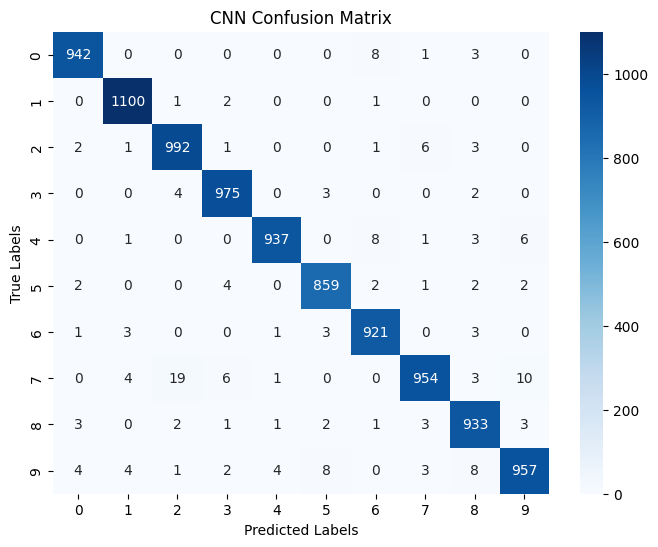

In [87]:
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn),axis = 1)
cm = confusion_matrix(y_test,y_pred_cnn)
plt.figure(figsize = (8,6))
sns.heatmap(cm,annot = True , fmt = "d" ,cmap = "Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

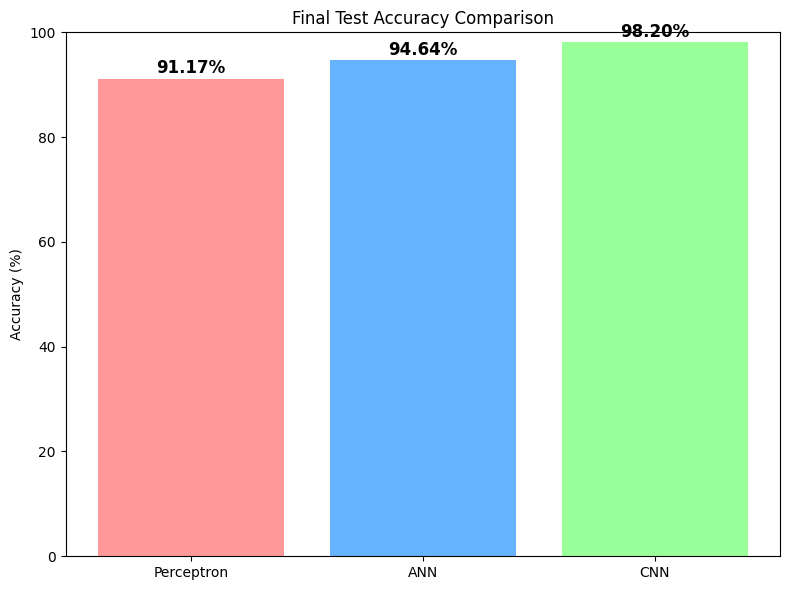

In [92]:
plt.close('all')   # purane empty figures band

final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

fig, ax = plt.subplots(figsize=(8,6))

bars = ax.bar(
    models,
    final_accs,
    color=['#ff9999', '#66b3ff', '#99ff99']
)

ax.set_title("Final Test Accuracy Comparison")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)

for bar, acc in zip(bars, final_accs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{acc:.2f}%",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()
plt.close()